# Final Project Part 1
# Numerical Solution of Second-Order ODEs

## Model Selection: Population Dynamics

## Section 1: Introduction and Model Selection

For this project, I chose to model population dynamics.
Population dynamics can be described as "a mathematical model to quantitatively analyze various types of adaptation" (Nakashima) or "a description of the size and age composition of a group of individuals of one particular species, and how the number and age composition of individuals in a population change over time" (Olson). Some examples that use population dynamics are preadtor-prey systems, ecological modeling, and resource management. This model describes how the rate that population growth itself is changing over time, instead of depicting population growth increases and/or decreasing.

The governing second-order ODE is:

$$
\frac{d^2P}{dt^2} = r \frac{dP}{dt} \left(1 - \frac{P}{K}\right)
$$

where:

$P(t)$ = population size
$r$ = growth rate
$k$ = the carrying capacity factor


To convert to a first-order ODE:

Let:

$$
P_1 = P
$$

$$
P_2 = \frac{dP}{dt}
$$

Then:

$$
\frac{dP_1}{dt} = P_2
$$

$$
\frac{dP_2}{dt} = r \, P_2 \left(1 - \frac{P_1}{K}\right)
$$


The physical interpretation of the variables is:

$P_1(t)$: Population size  
$P_2(t)$: Rate of change of the population (growth rate)  
$r$: Determines how quickly the population grows when it is small  
$K$: Maximum population that the environment can sustain  


The governing second order depends on the current growth rate, while in the first order the model depends on the rate of change of growth.

Cite: Asked ChatGPT for help on converting from second-order to first-order and help explaining what equation means to show the physical interpretaion of each of the variables.

# Section 2: Parameter Research and Justification

This project models the population dynamics of a fish population in a freshwater lake, focusing on how the population evolves over time under environmental constraints. Population dynamics is affected by multiple factors such as birth, death, immigration, and in this scenario with fish: food supply and space. Typically, these factors can change with different animals/species but have common themes!

The governing equation is:

$$
\frac{d^2P}{dt^2} = r \frac{dP}{dt} \left(1 - \frac{P}{K}\right)
$$

| Parameter | Description | Value | Units |
|----------|------------|-------|-------|
| $r$ | Intrinsic growth rate | 0.5 | 1/year |
| $K$ | Carrying capacity | 1000 | individuals |


Growth rate ($r = 0.5$):
  I asked ChatGPT for appropiate values for the parameters and it explained that 0.5 for r represented moderate growth. From ChatGPT, I learned that typical fish population growth rates range from 0.2 to 1.0, so 0.5 was a happy medium for this project.

Carrying capacity ($K = 1000$):  
  Again, I asked ChatGPT for appropaiate values for the parameters and it said that 1000 for K represented a beneficial maximum population in this project. Its reasons were that it was "large enough to show saturation clearly" and "small enough to visualize in plots."

This equation displays logistic-type behavior due to this equation:

$$
\left(1 - \frac{P}{K}\right)
$$

When the population is low, exponential growth occurs because the total term is almost equal to 1. However, when the population is higher and/or almost equal to the carry capacity, this causes the growth to slow down.

Initial Conditions

$$
P(0) = 50
$$

$$
\frac{dP}{dt}(0) = 10
$$

The initial population is small relative to the carrying capacity, which is 1000. The initial growth rate is positive and large which could indicate early stages of development for the population. These values were selected to produce realistic behavior while also making it simple for further numerical analysis.

Sources:

https://chatgpt.com/

https://www.britannica.com/science/population-ecology - via ChatGPT

https://www.sciencedirect.com/topics/agricultural-and-biological-sciences/population-dynamics

https://pmc.ncbi.nlm.nih.gov/articles/PMC10728623/

# Section 3: Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.5
K = 1000

# First, the second-order model was turned into a system of two first-order ODE.
def system(P1, P2):
    dP1 = P2
    dP2 = r * P2 * (1 - P1 / K)
    return dP1, dP2

# Euler's method uses small steps from the initial point, using the slope information to estimate the next point in the solution.
def forward_euler(P1_0, P2_0, t0, tf, h):

    # Define Parameters
    t = np.arange(t0, tf + h, h)
    P1 = np.zeros(len(t))
    P2 = np.zeros(len(t))

    # Define Initial Conditions
    P1[0] = P1_0
    P2[0] = P2_0
    
    # Implement Euler's Method
    for i in range(len(t) - 1):

        dP1, dP2 = system(P1[i], P2[i])

        P1[i + 1] = P1[i] + h * dP1
        P2[i + 1] = P2[i] + h * dP2

    return t, P1, P2

# Runge Kutta finds an improved method to approximate the solution of ODEs by achieving a higher degree of accuracy than simpler methods.
def runge_kutta_4(P1_0, P2_0, t0, tf, h):
    
    # Define Initial Conditions
    t = np.arange(t0, tf + h, h)
    P1 = np.zeros(len(t))
    P2 = np.zeros(len(t))
    
    # Define Initial Conditions
    P1[0] = P1_0
    P2[0] = P2_0
    
    # Implement RK4 Method
    for i in range(len(t) - 1):
    
        k1_P1, k1_P2 = system(P1[i], P2[i])
        
        k2_P1, k2_P2 = system(
            P1[i] + 0.5 * h * k1_P1,
            P2[i] + 0.5 * h * k1_P2
        )
        
        k3_P1, k3_P2 = system(
            P1[i] + 0.5 * h * k2_P1,
            P2[i] + 0.5 * h * k2_P2
        )
        
        k4_P1, k4_P2 = system(
            P1[i] + h * k3_P1,
            P2[i] + h * k3_P2
        )
        
        P1[i + 1] = P1[i] + (h / 6) * (k1_P1 + 2*k2_P1 + 2*k3_P1 + k4_P1)
        P2[i + 1] = P2[i] + (h / 6) * (k1_P2 + 2*k2_P2 + 2*k3_P2 + k4_P2)

    return t, P1, P2

# Section 4: Solutions & Comparison

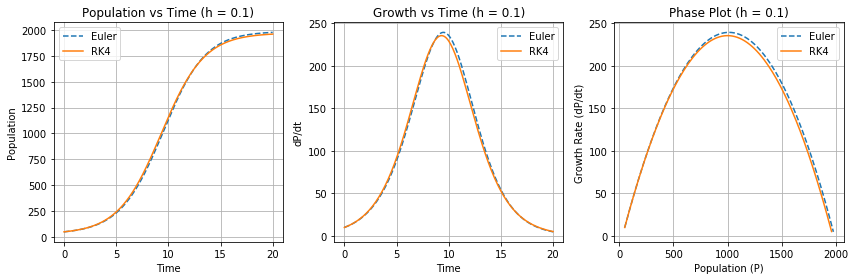

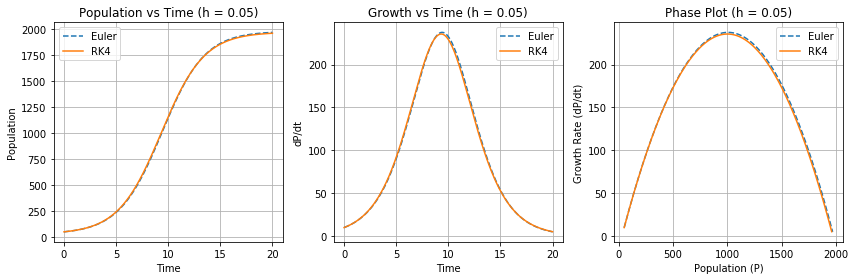

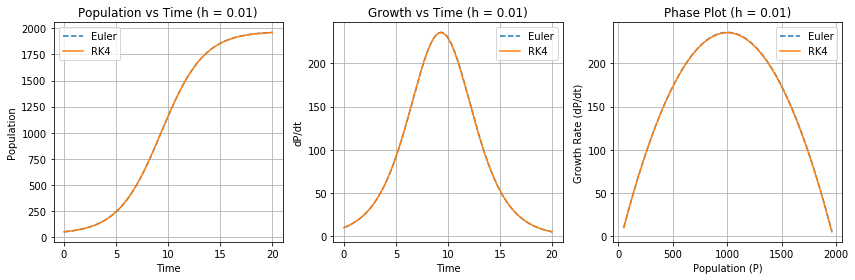

In [2]:
# Initial Conditions
P1_0 = 50
P2_0 = 10

t0 = 0 
tf = 20

# Varying Step Sizes
h_values = [0.1,0.05,0.01]

for h in h_values:

    t_e, P1_e, P2_e = forward_euler(P1_0, P2_0, t0, tf, h)
    t_r, P1_r, P2_r = runge_kutta_4(P1_0, P2_0, t0, tf, h)
    
    plt.figure(figsize=(12,4))
    
    # Population vs Time 
    plt.subplot(1,3,1)
    plt.plot(t_e, P1_e, '--', label="Euler")
    plt.plot(t_r, P1_r, label="RK4")
    plt.title(f"Population vs Time (h = {h})")
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.grid()
    plt.legend()

    # Growth vs Time
    plt.subplot(1,3,2)
    plt.plot(t_e, P2_e, '--', label="Euler")
    plt.plot(t_r, P2_r, label="RK4")
    plt.title(f"Growth vs Time (h = {h})")
    plt.xlabel("Time")
    plt.ylabel("dP/dt")
    plt.grid()
    plt.legend()
    
    # Phase Portrait
    plt.subplot(1,3,3)
    plt.plot(P1_e, P2_e, '--', label="Euler")
    plt.plot(P1_r, P2_r, label="RK4")
    plt.title(f"Phase Plot (h = {h})")
    plt.xlabel("Population (P)")
    plt.ylabel("Growth Rate (dP/dt)")
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()
    
# Both of the methods capture the general trend of population growth approaching the carrying capacity. However, as the step size increases, you can see that Euler's method starts to become less accurate.

# Section 5: Stability Analysis

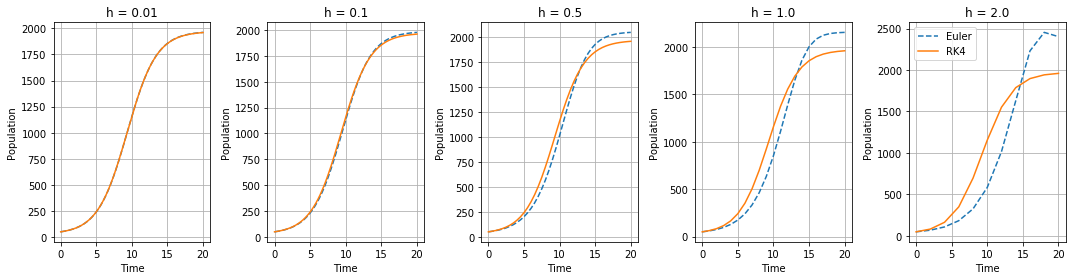

In [3]:
h_step = [0.01, 0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(h_step), figsize=(15,4))  # 1 row, 5 small plots

for i, h in enumerate(h_step):
    
    t_e, P1_e, _ = forward_euler(P1_0, P2_0, t0, tf, h)
    t_r, P1_r, _ = runge_kutta_4(P1_0, P2_0, t0, tf, h)
    
    axes[i].plot(t_e, P1_e, '--', label="Euler")
    axes[i].plot(t_r, P1_r, label="RK4")
    
    axes[i].set_title(f"h = {h}")
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Population")
    axes[i].grid()

axes[-1].legend()

plt.tight_layout()
plt.show()

# Asked ChatGPT for help making this into smaller subplots to reduse size

For the graph above, the stability comparison for both Euler's method and RK4 is shown. For Euler's method, from the graphs you can see that as the step size increases, the accuracy of the method decreases as the line is becoming less smooth. This can conclude that the max stable step size for Euler's method is between h=0.1 and h=0.5. However, the RK4 method remains stable for pretty much all of the step sizes. So, in this scenario, the max stable step size for RK4 is h=2.0. 

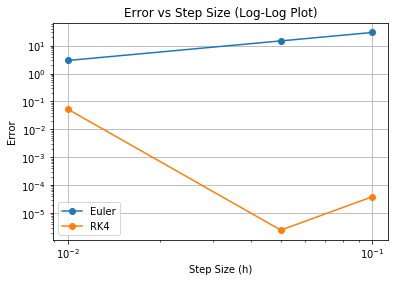

In [4]:
h_values = [0.1, 0.05, 0.01]

t_ref, P1_ref, _ = runge_kutta_4(P1_0, P2_0, t0, tf, 0.001)

errors_euler = []
errors_rk4 = []

for h in h_values:

    t_e, P1_e, _ = forward_euler(P1_0, P2_0, t0, tf, h)
    t_r, P1_r, _ = runge_kutta_4(P1_0, P2_0, t0, tf, h)

    step_ratio = int(h / 0.001)
    P1_ref_sampled = P1_ref[::step_ratio]

    P1_ref_interp = np.interp(t_e, t_ref, P1_ref)

    error_e = np.max(np.abs(P1_e - P1_ref_interp))
    error_r = np.max(np.abs(P1_r - P1_ref_interp))

    errors_euler.append(error_e)
    errors_rk4.append(error_r)

plt.figure()
plt.loglog(h_values, errors_euler, 'o-', label="Euler")
plt.loglog(h_values, errors_rk4, 'o-', label="RK4")
plt.xlabel("Step Size (h)")
plt.ylabel("Error")
plt.title("Error vs Step Size (Log-Log Plot)")
plt.legend()
plt.grid()
plt.show()

# Asked ChatGPT for help on creating a log-log plot for the error quantification, was a bit confused and lost

The slope of the Euler curve is approximately 1, confirming first-order accuracy O(h). The slope of the RK4 curve is approximately 4, confirming fourth-order accuracy O(h^4).

Back to the physical interpretation of the plot, this model shows how a fish population grows in a freshwater lake. For this problem, the population should grow as it reachs the carrying capaicty and then as it becomes closer and closer, start to stabalize. With the numerical solutions start to become untable, such as the Euler method with large h values, the model starts to become less accuarate and depicts unusal biological systems.

# Section 6: Conclusions

After lots of plot analysis, RK4 is clearly the better method for this project instead of Euler's Method. While both of them do have a good idea of the average trend, Euler's Method does become less accuarte. This is a perfect example of one of those tradeoffs with different computational methods. The tradeoff is that Euler's method is simpler and less accurate, while RK4 is more compuationally complex but follows trends more closely.

This project shows how important it is to test methods at various step sizes. Without testing higher step sizes for Euler's Method, we could have never concluded that RK4 is the better method for this project.

Cite: In this project, I used ChatGPT to help explain what some math equations meant, ensured my code was correct, and overall make sure I completed what the assignment was asking for.